In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from subprocess import check_output
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pandas.plotting import lag_plot
from pandas import datetime
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('///Users/markjuvert/Desktop/RNN/1420.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-01-02,5.00,5.0,4.70,4.70,4.70,7200
1,2014-01-03,4.85,5.0,4.65,4.75,4.75,6400
2,2014-01-06,4.60,5.0,4.60,4.85,4.85,7000
3,2014-01-07,4.95,5.1,4.95,5.10,5.10,3600
4,2014-01-08,5.10,5.3,4.95,5.05,5.05,8800


In [3]:
print(df.head())
print(df.shape)
print(df.columns)

         Date  Open  High   Low  Close  Adj Close  Volume
0  2014-01-02  5.00   5.0  4.70   4.70       4.70    7200
1  2014-01-03  4.85   5.0  4.65   4.75       4.75    6400
2  2014-01-06  4.60   5.0  4.60   4.85       4.85    7000
3  2014-01-07  4.95   5.1  4.95   5.10       5.10    3600
4  2014-01-08  5.10   5.3  4.95   5.05       5.05    8800
(1575, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


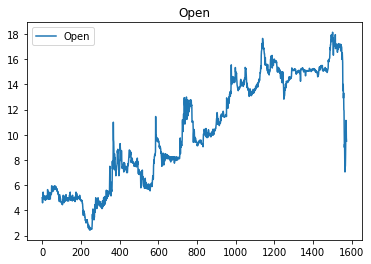

In [4]:
df[['Open']].plot()
plt.title("Open")
plt.show()

Text(0.5, 1.0, 'Limestone Cumulative Returns')

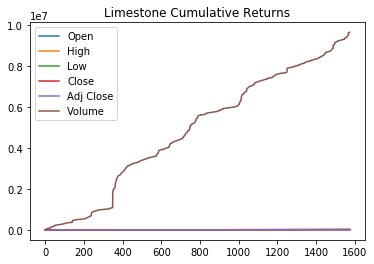

In [5]:
# Comulative Return
dr = df.cumsum()
dr.plot()
plt.title('Limestone Cumulative Returns')

Text(0.5, 1.0, 'Limestone Autocorrelation plot')

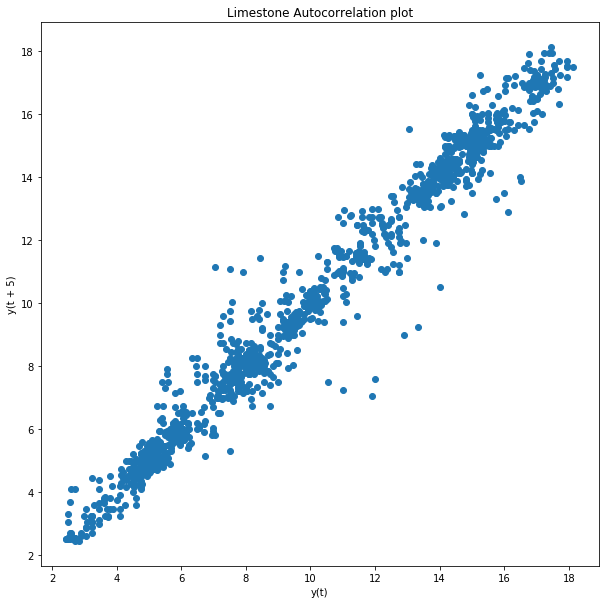

In [6]:
plt.figure(figsize=(10,10))
lag_plot(df['Open'], lag=5)
plt.title('Limestone Autocorrelation plot')

In [7]:
df['Date'][1574]

'2020-04-03'

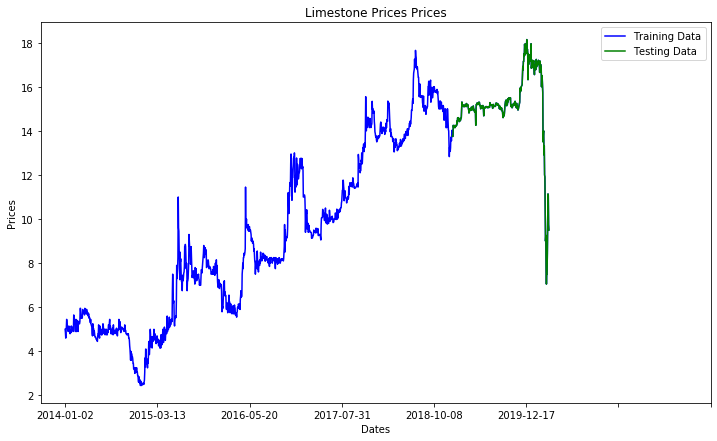

In [8]:
train_data, test_data = df[0:int(len(df)*0.8)], df[int(len(df)*0.8):]
plt.figure(figsize=(12,7))
plt.title('Limestone Prices Prices')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.plot(df['Open'], 'blue', label='Training Data')
plt.plot(test_data['Open'], 'green', label='Testing Data')
plt.xticks(np.arange(0,2327, 300), df['Date'][0:2327:300])
plt.legend()

In [9]:
def smape_kun(y_true, y_pred):
    return np.mean((np.abs(y_pred - y_true) * 200/ (np.abs(y_pred) + np.abs(y_true))))

In [15]:
train_ar = train_data['Open'].values
test_ar = test_data['Open'].values

# https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/
history = [x for x in train_ar]
print(type(history))
predictions = list()
for t in range(len(test_ar)):
    model = ARIMA(history, order=(5,1,1))
    model_fit = model.fit(disp=0)
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test_ar[t]
    history.append(obs)
    #print('predicted=%f, expected=%f' % (yhat, obs))
error = mean_squared_error(test_ar, predictions)
print('Testing Mean Squared Error: %.3f' % error)
error2 = smape_kun(test_ar, predictions)
print('Symmetric mean absolute percentage error: %.3f' % error2)

<class 'list'>
Testing Mean Squared Error: 0.126
Symmetric mean absolute percentage error: 10.120


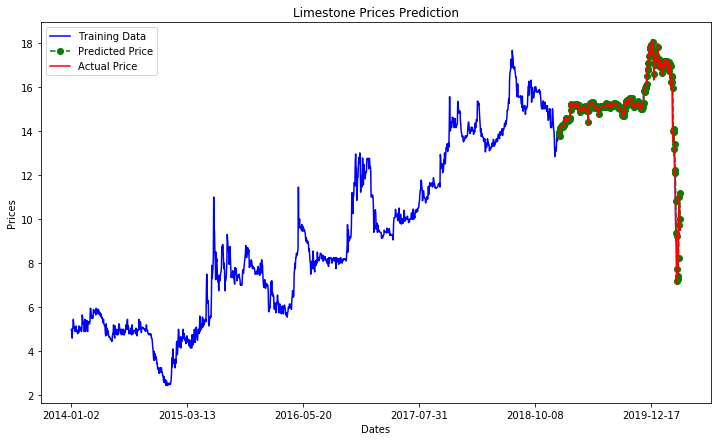

In [11]:
plt.figure(figsize=(12,7))
plt.plot(df['Open'], 'green', color='blue', label='Training Data')
plt.plot(test_data.index, predictions, color='green', marker='o', linestyle='dashed', 
         label='Predicted Price')
plt.plot(test_data.index, test_data['Open'], color='red', label='Actual Price')
plt.title('Limestone Prices Prediction')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.xticks(np.arange(0,1574, 300), df['Date'][0:1574:300])
plt.legend()

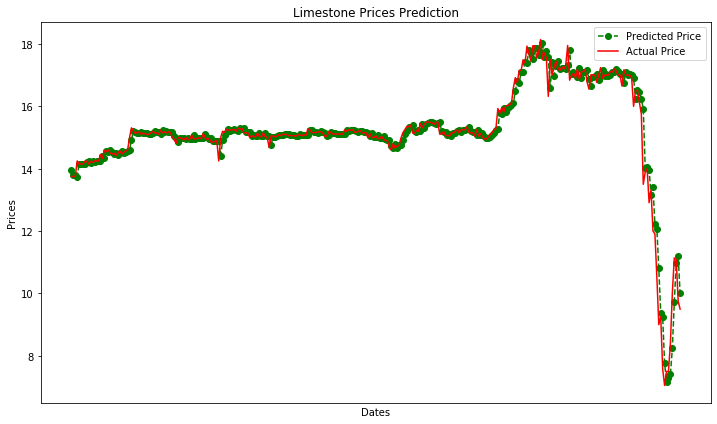

In [12]:
plt.figure(figsize=(12,7))
plt.plot(test_data.index, predictions, color='green', marker='o', linestyle='dashed', 
         label='Predicted Price')
plt.plot(test_data.index, test_data['Open'], color='red', label='Actual Price')
plt.xticks(np.arange(1574,1574, 60), df['Date'][1574:1574:60])
plt.title('Limestone Prices Prediction')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.legend()

In [14]:
#Print MSE to see how good the model is
error = mean_squared_error(test_ar, predictions)
print('Test Mean Squared Error (smaller the better fit): %.3f' % error)

Test Mean Squared Error (smaller the better fit): 0.124


In [19]:
print('Test MSE: %.3f' % error)

Test MSE: 0.124
